In [5]:
# Step 3: Canonical Bounding Box → Mask Generation (FULL DATASET)

# Step 3 - Canonical Bounding Box to Pseudo-Mask Generation

In this step, 3D bounding box annotations from the MELA dataset are converted into volumetric pseudo-masks.

Each CT volume is first transformed into canonical RAS orientation. Then, lesion centers are mapped into canonical voxel space using affine transformations. Bounding boxes are constructed around these centers and converted into binary masks.

This process is applied to the entire dataset to generate training-ready pseudo-labels.

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
!pip install nibabel pandas tqdm -q

In [15]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
from tqdm import tqdm

In [23]:
BASE = "/content/drive/MyDrive/MELA"

TRAIN_DIR = os.path.join(BASE, "images", "train")
VAL_DIR = os.path.join(BASE, "images", "val")
ANN_DIR = os.path.join(BASE, "annotations")

DRIVE_MASK_TRAIN_DIR = os.path.join(BASE, "masks", "train")
DRIVE_MASK_VAL_DIR = os.path.join(BASE, "masks", "val")

# Colab local output klasörleri
LOCAL_MASK_TRAIN_DIR = "/content/masks/train"
LOCAL_MASK_VAL_DIR = "/content/masks/val"

os.makedirs(DRIVE_MASK_TRAIN_DIR, exist_ok=True)
os.makedirs(DRIVE_MASK_VAL_DIR, exist_ok=True)
os.makedirs(LOCAL_MASK_TRAIN_DIR, exist_ok=True)
os.makedirs(LOCAL_MASK_VAL_DIR, exist_ok=True)

print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("ANN_DIR:", ANN_DIR)
print("LOCAL_MASK_TRAIN_DIR:", LOCAL_MASK_TRAIN_DIR)
print("LOCAL_MASK_VAL_DIR:", LOCAL_MASK_VAL_DIR)

TRAIN_DIR: /content/drive/MyDrive/MELA/images/train
VAL_DIR: /content/drive/MyDrive/MELA/images/val
ANN_DIR: /content/drive/MyDrive/MELA/annotations
LOCAL_MASK_TRAIN_DIR: /content/masks/train
LOCAL_MASK_VAL_DIR: /content/masks/val


In [24]:
df_ann = pd.read_csv(os.path.join(ANN_DIR, "mela_train_val_annotations.csv"))
print("Toplam annotation:", len(df_ann))
df_ann.head()

Toplam annotation: 884


,public_id,coordX,coordY,coordZ,x_length,y_length,z_length
0,mela_0001,300,153,278,62,61,37
1,mela_0002,265,182,274,42,39,38
2,mela_0003,259,269,315,111,81,100
3,mela_0004,317,309,360,112,115,138
4,mela_0005,284,187,345,40,59,54


In [18]:
df_ann = pd.read_csv(os.path.join(ANN_DIR, "mela_train_val_annotations.csv"))
print("Toplam annotation:", len(df_ann))
df_ann.head()

In [26]:
def generate_mask_for_volume(nifti_path, df_ann, save_path):
    """
    Tek bir NIfTI hacmi için bbox tabanlı pseudo-mask üretir ve kaydeder.
    """
    # Görüntüyü yükle
    img = nib.load(nifti_path)
    img_canon = nib.as_closest_canonical(img)
    img_data_canon = img_canon.get_fdata()

    sample_id = os.path.basename(nifti_path).replace(".nii.gz", "")

    # Annotation satırlarını al
    ann_rows = df_ann[df_ann["public_id"] == sample_id]

    if len(ann_rows) == 0:
        raise ValueError(f"Annotation bulunamadı: {sample_id}")

    # Boş mask
    mask = np.zeros_like(img_data_canon, dtype=np.uint8)

    # Her bbox için maskeyi doldur
    for _, row in ann_rows.iterrows():
        cx = float(row["coordX"])
        cy = float(row["coordY"])
        cz = float(row["coordZ"])

        lx = float(row["x_length"])
        ly = float(row["y_length"])
        lz = float(row["z_length"])

        # Orijinal voxel -> world
        center_old = np.array([cx, cy, cz, 1.0])
        center_world = img.affine @ center_old

        # World -> canonical voxel
        center_new = np.linalg.inv(img_canon.affine) @ center_world
        cx_new, cy_new, cz_new = center_new[:3]

        # BBox sınırları
        x_min = int(round(cx_new - lx / 2))
        x_max = int(round(cx_new + lx / 2))

        y_min = int(round(cy_new - ly / 2))
        y_max = int(round(cy_new + ly / 2))

        z_min = int(round(cz_new - lz / 2))
        z_max = int(round(cz_new + lz / 2))

        # Sınır kontrolü
        x_min = max(0, x_min)
        x_max = min(mask.shape[0], x_max)

        y_min = max(0, y_min)
        y_max = min(mask.shape[1], y_max)

        z_min = max(0, z_min)
        z_max = min(mask.shape[2], z_max)

        # Maskeyi doldur
        mask[x_min:x_max, y_min:y_max, z_min:z_max] = 1

    # Kaydet
    mask_img = nib.Nifti1Image(mask.astype(np.uint8), affine=img_canon.affine)
    nib.save(mask_img, save_path)

In [31]:
train_files = sorted([f for f in os.listdir(TRAIN_DIR) if f.endswith(".nii.gz")])

failed_train = []

for f in tqdm(train_files, desc="Generating train masks"):
    output_name = f.replace(".nii.gz", "_mask.nii.gz")
    local_output_path = os.path.join(LOCAL_MASK_TRAIN_DIR, output_name)

    # Zaten local'de varsa atla
    if os.path.exists(local_output_path):
        continue

    input_path = os.path.join(TRAIN_DIR, f)

    try:
        generate_mask_for_volume(input_path, df_ann, local_output_path)
    except Exception as e:
        print(f"Hata ({f}): {e}")
        failed_train.append((f, str(e)))

print("Train tamamlandı.")
print("Başarısız train dosya sayısı:", len(failed_train))

Generating train masks: 100%|██████████| 260/260 [23:56<00:00,  5.53s/it]

Train tamamlandı.
Başarısız train dosya sayısı: 0


In [33]:
print("Train image count:", len(train_files))
print("Generated local train masks:", len(os.listdir(LOCAL_MASK_TRAIN_DIR)))
print("Failed train files:", len(failed_train))

Train image count: 260
Generated local train masks: 260
Failed train files: 0


In [34]:
import shutil
from tqdm import tqdm

copied = 0

for f in tqdm(os.listdir(LOCAL_MASK_TRAIN_DIR)):
    src = os.path.join(LOCAL_MASK_TRAIN_DIR, f)
    dst = os.path.join(DRIVE_MASK_TRAIN_DIR, f)

    if not os.path.exists(dst):
        shutil.copy2(src, dst)
        copied += 1

print("Drive'a kopyalanan mask sayısı:", copied)

100%|██████████| 260/260 [00:07<00:00, 37.09it/s]

Drive'a kopyalanan mask sayısı: 260


In [35]:
print(len(os.listdir(DRIVE_MASK_TRAIN_DIR)))

260


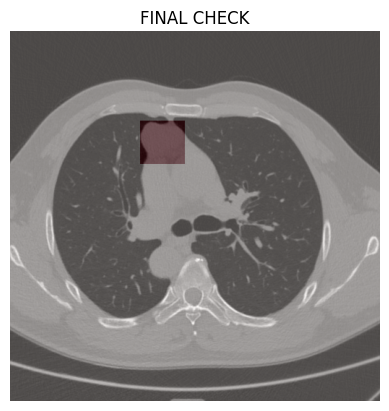

In [36]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

test_file = train_files[0]

img = nib.load(os.path.join(TRAIN_DIR, test_file))
img = nib.as_closest_canonical(img)
img_data = img.get_fdata()

mask = nib.load(os.path.join(DRIVE_MASK_TRAIN_DIR, test_file.replace(".nii.gz", "_mask.nii.gz")))
mask_data = mask.get_fdata()

slices = np.where(mask_data.sum(axis=(0,1)) > 0)[0]
z = slices[len(slices)//2]

plt.imshow(img_data[:, :, z].T, cmap="gray", origin="lower")
plt.imshow(mask_data[:, :, z].T, cmap="Reds", alpha=0.3, origin="lower")
plt.title("FINAL CHECK")
plt.axis("off")
plt.show()